In [1]:
%reload_ext autoreload
%autoreload 2


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize

from PIL import Image

from processing import crop_faces
from training import (
    CROPS_DIR, BATCH_SIZE, NUM_EPOCHS, LEARNING_RATE, VAL_SPLIT, SEED, CHECKPOINTS,
    get_device, build_dataloaders, compute_class_weights, build_model, run_epoch,
)
from evaluation import evaluate_model


## 1. Build the crops dataset

In [3]:
crop_faces(
    image_dir="../data/images",
    annotation_dir="../data/annotations",
    output_dir="../data/crops",
)


Saved 3603 face crops, skipped 469 tiny/degenerate boxes


## 2. Train

In [4]:
torch.manual_seed(SEED)

device = get_device()
print(f"Using device: {device}")

train_loader, val_loader, classes, train_targets, val_paths = build_dataloaders(CROPS_DIR, BATCH_SIZE, VAL_SPLIT, SEED)
print(f"Classes: {classes}")

class_weights = compute_class_weights(train_targets, len(classes)).to(device) # not used, initially used for loss weighting
print(f"Class weights: {class_weights.tolist()}")

model = build_model(architecture='EfficientNet', num_classes=len(classes)).to(device)
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.1, patience=3)  


Using device: mps
Classes: ['mask_weared_incorrect', 'with_mask', 'without_mask']
Class weights: [10.11228084564209, 0.4174996316432953, 1.9766803979873657]


In [5]:
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_loss = float('inf')
patience, epochs_without_improvement = 10, 0

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer, device, train=True)
    val_loss, val_acc = run_epoch(model, val_loader, criterion, optimizer, device, train=False)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch + 1}/{NUM_EPOCHS} | train loss {train_loss:.4f} acc {train_acc:.4f} | val loss {val_loss:.4f} acc {val_acc:.4f}")

    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_without_improvement = 0
        torch.save(model.state_dict(), CHECKPOINTS['EfficientNet'])
        print(f"  Saved new best model (val loss {val_loss:.4f})")
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= patience:
            print(f"No validation loss improvement, stop at epoch {epoch + 1}")
            break 

print(f"Training done. Best validation loss: {best_val_loss:.4f}")


Epoch 1/40 | train loss 0.6523 acc 0.7394 | val loss 0.2669 acc 0.9126
  Saved new best model (val loss 0.2669)
Epoch 2/40 | train loss 0.2059 acc 0.9368 | val loss 0.1907 acc 0.9293
  Saved new best model (val loss 0.1907)
Epoch 3/40 | train loss 0.1292 acc 0.9611 | val loss 0.1101 acc 0.9667
  Saved new best model (val loss 0.1101)
Epoch 4/40 | train loss 0.0963 acc 0.9754 | val loss 0.1039 acc 0.9709
  Saved new best model (val loss 0.1039)
Epoch 5/40 | train loss 0.0911 acc 0.9722 | val loss 0.0982 acc 0.9681
  Saved new best model (val loss 0.0982)
Epoch 6/40 | train loss 0.0559 acc 0.9847 | val loss 0.0874 acc 0.9723
  Saved new best model (val loss 0.0874)
Epoch 7/40 | train loss 0.0419 acc 0.9885 | val loss 0.0828 acc 0.9806
  Saved new best model (val loss 0.0828)
Epoch 8/40 | train loss 0.0518 acc 0.9833 | val loss 0.1059 acc 0.9667
Epoch 9/40 | train loss 0.0305 acc 0.9920 | val loss 0.1144 acc 0.9709
Epoch 10/40 | train loss 0.0295 acc 0.9910 | val loss 0.1058 acc 0.9750
Ep

## 3. Training curves

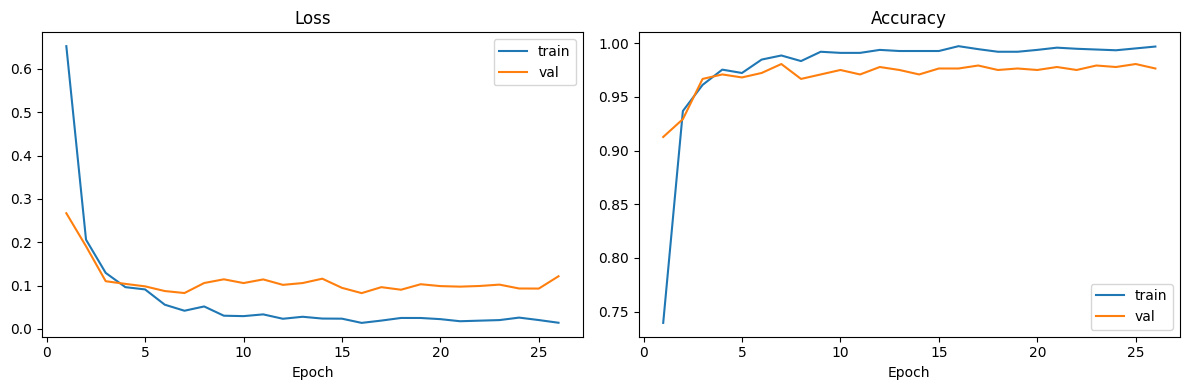

In [6]:
epochs = range(1, epoch + 2)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, history["train_loss"], label="train")
axes[0].plot(epochs, history["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(epochs, history["train_acc"], label="train")
axes[1].plot(epochs, history["val_acc"], label="val")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()


## 4. Evaluate on validation set

Loads the best checkpoint saved during training and reports precision/recall/F1 per class.

In [7]:
results = evaluate_model(checkpoint_path=CHECKPOINTS['EfficientNet'], architecture="EfficientNet")
print(results["report"])


                       precision    recall  f1-score   support

mask_weared_incorrect       0.74      0.61      0.67        23
            with_mask       0.99      0.99      0.99       576
         without_mask       0.96      0.97      0.96       122

             accuracy                           0.98       721
            macro avg       0.89      0.86      0.87       721
         weighted avg       0.98      0.98      0.98       721



## 5. Confusion matrix


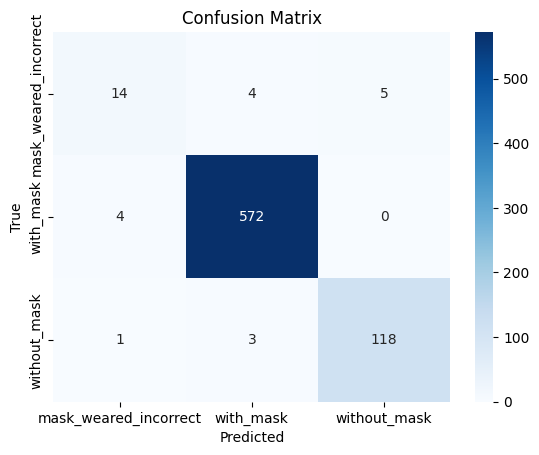

In [8]:
sns.heatmap(
    results["confusion_matrix"], annot=True, fmt="d",
    xticklabels=results["classes"], yticklabels=results["classes"], cmap="Blues",
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


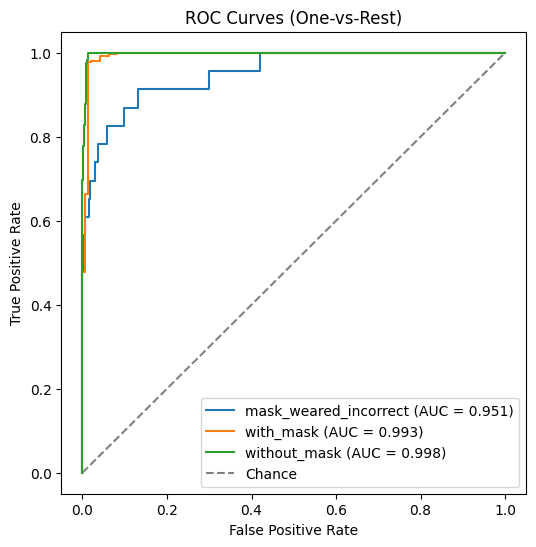

In [9]:
y_true = np.array(results["y_true"])
y_score = np.array(results["y_score"])
classes = results["classes"]

y_true_bin = label_binarize(y_true, classes=range(len(classes)))

plt.figure(figsize=(6, 6))
for i, class_name in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_name} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (One-vs-Rest)")
plt.legend()
plt.show()

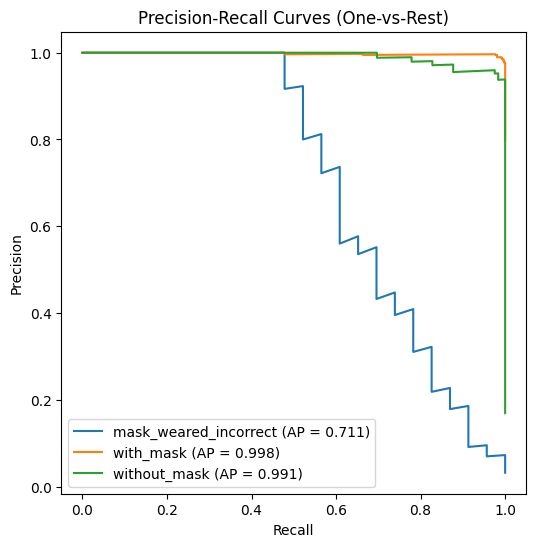

In [10]:

plt.figure(figsize=(6, 6))
for i, class_name in enumerate(classes):
    precision, recall, thresholds = precision_recall_curve(y_true_bin[:, i], y_score[:, i])
    ap = average_precision_score(y_true_bin[:, i], y_score[:, i])
    plt.plot(recall, precision, label=f"{class_name} (AP = {ap:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves (One-vs-Rest)")
plt.legend()
plt.show()

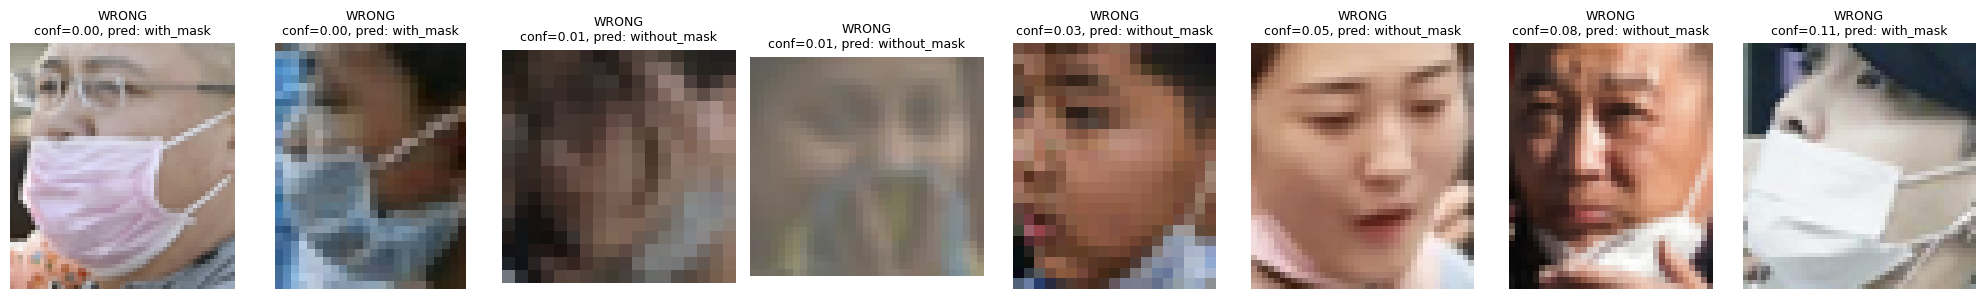

In [11]:
target_idx = classes.index("mask_weared_incorrect")
y_true = np.array(results["y_true"])
y_score = np.array(results["y_score"])
y_pred = np.array(results["y_pred"])
paths = results["val_paths"]

# every actual mask_weared_incorrect example in the val set
rare_indices = np.where(y_true == target_idx)[0]

# how confident the model was in the CORRECT class, for each of them
rare_confidences = y_score[rare_indices, target_idx]

# sort lowest-confidence first 
order = np.argsort(rare_confidences)
sorted_indices = rare_indices[order]

n_show = 8
fig, axes = plt.subplots(1, n_show, figsize=(20, 3))
for ax, idx in zip(axes, sorted_indices[:n_show]):
    img = Image.open(paths[idx])
    ax.imshow(img)
    conf = y_score[idx, target_idx]
    pred_label = classes[y_pred[idx]]
    correct = "correct" if y_pred[idx] == target_idx else "WRONG"
    ax.set_title(f"{correct}\nconf={conf:.2f}, pred: {pred_label}", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

In [12]:
import cv2
for idx in sorted_indices[:8]:  # from the error-analysis cell, main.ipynb
    path = results["val_paths"][idx]
    img = cv2.imread(str(path))
    h, w = img.shape[:2]
    print(f"{path}: {min(h, w)}px")

../data/crops/mask_weared_incorrect/maksssksksss786_3.png: 53px
../data/crops/mask_weared_incorrect/maksssksksss453_6.png: 24px
../data/crops/mask_weared_incorrect/maksssksksss657_8.png: 18px
../data/crops/mask_weared_incorrect/maksssksksss760_1.png: 31px
../data/crops/mask_weared_incorrect/maksssksksss613_9.png: 19px
../data/crops/mask_weared_incorrect/maksssksksss130_0.png: 39px
../data/crops/mask_weared_incorrect/maksssksksss673_2.png: 34px
../data/crops/mask_weared_incorrect/maksssksksss761_0.png: 51px
